# E-Commerce Sales Analysis

## Project Objective

The goal of this project is to analyze e-commerce transaction data
to uncover insights about sales performance, customer behavior,
and product trends.

## Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [3]:
df = pd.read_csv("online_retail.csv", encoding="latin-1")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/10 8:26,3.39,17850.0,United Kingdom


## Dataset Overview

In [13]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Dataset information
df.info()

# Check missing values
df.isnull().sum()

Dataset Shape: (541910, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      541910 non-null  object 
 1   StockCode    541910 non-null  object 
 2   Description  540456 non-null  object 
 3   Quantity     541910 non-null  int64  
 4   InvoiceDate  541910 non-null  object 
 5   Price        541910 non-null  float64
 6   Customer ID  406830 non-null  float64
 7   Country      541910 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

## Data Cleaning

In [5]:
# Remove rows where Customer Id is missing
df = df.dropna(subset = ['Customer ID'])

# Convert invoicedate into datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove negative quantities (returns)
df = df[df['Quantity'] > 0]

# Remove negative Price
df = df[df['Price'] > 0]

## Feature Engineering

In [12]:
# Create Revenue column
df['Revenue'] = df['Quantity']*df['Price']

In [9]:
# Total Revenue
total_revenue = df['Revenue'].sum()
print("Total Revenue :", total_revenue)

Total Revenue : 8911425.904


## Exploratory Data Analysis

In [11]:
# Top Selling Products
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending = False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [14]:
# Top Revenue Generating Products
top_revenue_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending = False).head(10)
print(top_revenue_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77821.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64


In [15]:
# Top Customers by Spending
top_customers = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending = False).head(10)
print(top_customers)

Customer ID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64


In [17]:
# Revenue by Country
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending = False)
print(country_revenue.head(10))

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209042.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64


In [38]:
# Monthly Sales Trend
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Revenue'].sum()
print(monthly_sales)

Month
2010-01      46376.490
2010-02      47316.530
2010-03      23921.710
2010-05      31771.600
2010-06      31215.640
2010-07      53795.310
2010-08      39248.820
2010-09      38231.900
2010-10      33650.280
2010-12     227185.610
2011-01     601804.600
2011-02     487100.630
2011-03     646325.520
2011-04     602872.241
2011-05     719269.560
2011-06     688561.560
2011-07     735451.041
2011-08     608723.700
2011-09    1095174.872
2011-10     904826.420
2011-11    1043411.070
2011-12     205190.800
Freq: M, Name: Revenue, dtype: float64


In [29]:
# Average order value
order_value = df.groupby('Invoice')['Revenue'].sum()
avg_order_value = order_value.mean()
print("Average Order Value:", avg_order_value)

Average Order Value: 480.8669276926398


## Data Visualization

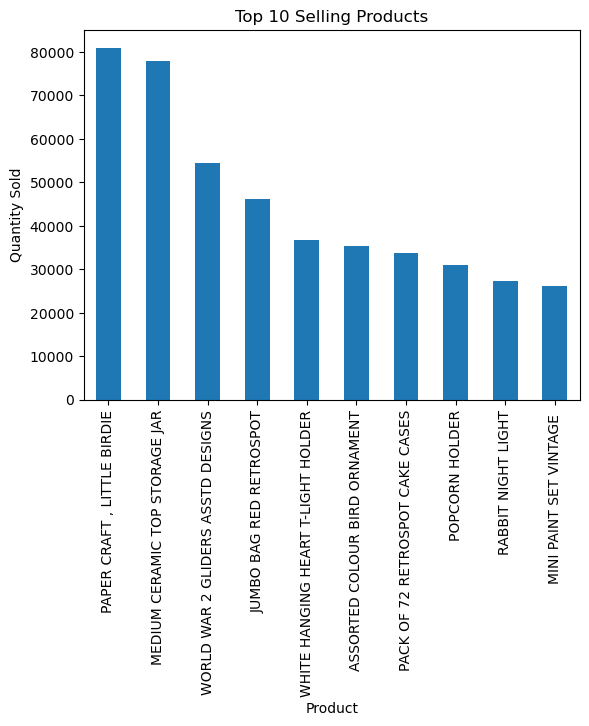

In [24]:
# Top Products
top_products.plot(kind = 'bar')

plt.title('Top 10 Selling Products')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')
plt.show()

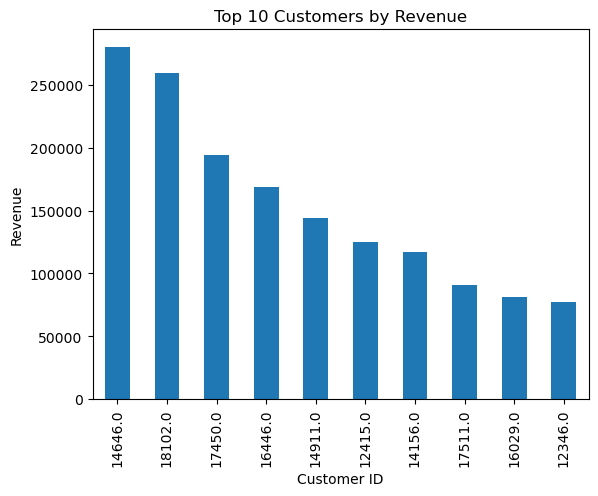

In [28]:
# top_customers
top_customers.plot(kind='bar')

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

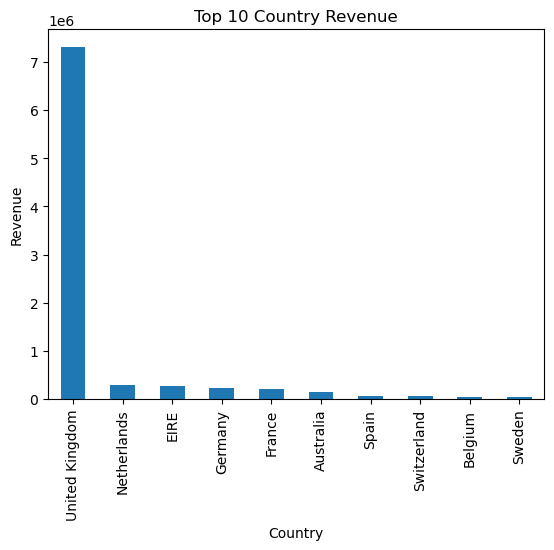

In [26]:
# Revenue by Country
country_revenue.head(10).plot(kind = 'bar')
plt.title('Top 10 Country Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.show()

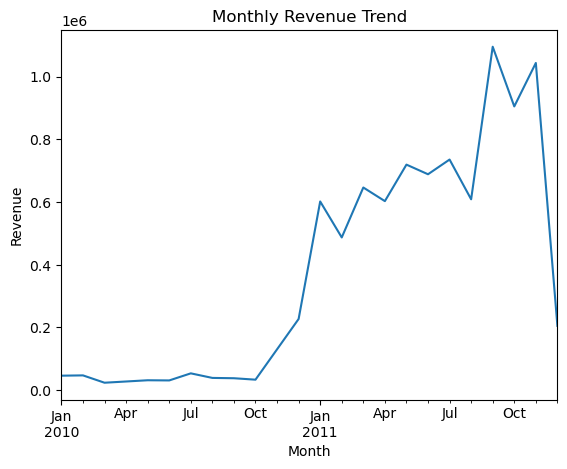

In [44]:
# Monthly Sales Trend
monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

## Key Business Insights

1. **United Kingdom Dominates Sales**
   - The majority of transactions and revenue come from the United Kingdom, making it the primary market for the business.

2. **Top Performing Products**
   - The analysis shows that a few products dominate total sales volume. 
   - The most sold product in the dataset is **PAPER CRAFT , LITTLE BIRDIE** with **80,995 units sold**.
   - Other highly popular products include **MEDIUM CERAMIC TOP STORAGE JAR (77,916 units)** and **WORLD WAR 2 GLIDERS ASSTD DESIGNS (54,415 units)**.
   - These products consistently appear among the highest selling items and contribute significantly to overall sales performance.

3. **High-Value Customers**

   - The analysis shows that a small group of customers contributes a significant portion of total revenue.
   - The highest spending customer in the dataset is **Customer ID 14646**, generating **£280,206** in total revenue.
   - Other top customers include **Customer ID 18102 (£259,657)** and **Customer ID 17450 (£194,550)**.
   - These high-value customers represent an important segment for the business and could be targeted through loyalty programs and personalized marketing strategies.


4. **Monthly Sales Patterns**

- The monthly revenue analysis shows strong growth in sales during the year 2011 compared to 2010.
- The highest monthly revenue was recorded in **September 2011 with £1,095,174**, followed by **November 2011 with £1,043,411**.
- Sales remained consistently high from **May 2011 to November 2011**, indicating a strong demand period during these months.
- In contrast, revenue was significantly lower during early 2010 months, showing that the business expanded rapidly over time.

5. **Product Returns Exist in the Dataset**
   - Some transactions contain negative quantities, which represent product returns. Certain products appear more frequently in return transactions and may require quality checks or improved product descriptions.


## Final Conclusion

This project analyzed an e-commerce transaction dataset to understand sales performance, customer behavior, and product demand patterns. 
The analysis revealed that revenue is highly concentrated among a small number of products, customers, and countries. 
Customer retention and high-performing products play a critical role in driving overall revenue. 
These insights can help businesses optimize product strategy, improve marketing efforts, and enhance customer engagement.